In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import kagglehub
import os

In [2]:
# Download latest version
path = kagglehub.dataset_download("blurredmachine/are-your-employees-burning-out")
train_csv_path = os.path.join(path, 'train.csv')
test_csv_path = os.path.join(path, 'test.csv')

100%|██████████| 425k/425k [00:00<00:00, 48.5MB/s]

Extracting files...


In [3]:
train = pd.read_csv(train_csv_path)

In [4]:
test = pd.read_csv(test_csv_path)

In [5]:
train.head(5)

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [6]:
print(train.shape)

(22750, 9)


**clean train dataset**

In [7]:
train.dtypes

,0
Employee ID,object
Date of Joining,object
Gender,object
Company Type,object
WFH Setup Available,object
Designation,float64
Resource Allocation,float64
Mental Fatigue Score,float64
Burn Rate,float64


**Drop employee id**<br>
**Encode Gender, Working From Home, Company Type in training dataset using pandas**<br>
**Create days since joining and drop date of joining**

In [8]:
df = train.copy()

# Drop ID
df = df.drop(columns=["Employee ID"])

# Convert date and create days_since_joined
df["Date of Joining"] = pd.to_datetime(df["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df["days_since_joined"] = (reference_date - df["Date of Joining"]).dt.days
df = df.drop(columns=["Date of Joining"])

# Binary encoding
df["gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["company_type"] = df["Company Type"].map({"Service": 1, "Product": 0})
df["is_wfh"] = df["WFH Setup Available"].map({"Yes": 1, "No": 0})

df = df.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

print(df.head())

   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0          2.0                  3.0                   3.8       0.16   
1          1.0                  2.0                   5.0       0.36   
2          2.0                  NaN                   5.8       0.49   
3          1.0                  1.0                   2.6       0.20   
4          3.0                  7.0                   6.9       0.52   

   days_since_joined  gender  company_type  is_wfh  
0                 92       0             1       0  
1                 31       1             1       1  
2                296       0             0       1  
3                 58       1             1       1  
4                160       0             1       0  


**Feature Imputation**
- add a column for burn rate classification

In [9]:
df["High Burnout"] = np.where(df["Burn Rate"] > df["Burn Rate"].median(), True, False)

**Burnout Risk Factor**
- Create new column rurnout risk factor
- Perform one hot encoding for burnout risk

In [10]:
def burnout_tiers(burn_rate):
    if burn_rate < 0.31:
        return "Low Risk"
    elif burn_rate < 0.59:
        return "Moderate Risk"
    else:
        return "High Risk"

In [11]:
df["Burnout Risk Factor"] = df["Burn Rate"].apply(burnout_tiers)

In [13]:
dummies1 = pd.get_dummies(df[["Burnout Risk Factor"]])
df = pd.concat([df, dummies1], axis=1)
df.head(5)

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk
0,2.0,3.0,3.8,0.16,92,0,1,0,False,Low Risk,False,True,False
1,1.0,2.0,5.0,0.36,31,1,1,1,False,Moderate Risk,False,False,True
2,2.0,NaN,5.8,0.49,296,0,0,1,True,Moderate Risk,False,False,True
3,1.0,1.0,2.6,0.20,58,1,1,1,False,Low Risk,False,True,False
4,3.0,7.0,6.9,0.52,160,0,1,0,True,Moderate Risk,False,False,True


**Data Hygiene**
- Return the shape of the dataset
- Check data types
- return a heatmap of null values is the missing data random or systematic
- uniqueness: identify duplicate rows, or columns with zero variance

In [16]:
df.shape

(22750, 13)

In [18]:
df.dtypes

,0
Designation,float64
Resource Allocation,float64
Mental Fatigue Score,float64
Burn Rate,float64
days_since_joined,int64
gender,int64
company_type,int64
is_wfh,int64
High Burnout,bool
Burnout Risk Factor,object


**Assess Missingness**
- Return missingness heatmap of missing values for the target values of burn rate, working hours and mental fatigue score, is the missing data random or systematic?
- the low missingness correlation & the permutation test is consistent with MCAR

In [19]:
dfc = df.copy()

missing_count = dfc.isnull().sum()
missing_pct = (dfc.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct
}).sort_values("missing_percent", ascending=False)

print(missing_summary)

                                   missing_count  missing_percent
Mental Fatigue Score                        2117             9.31
Resource Allocation                         1381             6.07
Burn Rate                                   1124             4.94
Designation                                    0             0.00
days_since_joined                              0             0.00
gender                                         0             0.00
company_type                                   0             0.00
is_wfh                                         0             0.00
High Burnout                                   0             0.00
Burnout Risk Factor                            0             0.00
Burnout Risk Factor_High Risk                  0             0.00
Burnout Risk Factor_Low Risk                   0             0.00
Burnout Risk Factor_Moderate Risk              0             0.00


In [20]:
from scipy.stats import ks_2samp

dfc = df.copy()

# Missingness indicators
dfc["mfs_missing"] = dfc["Mental Fatigue Score"].isna().astype(int)
dfc["ra_missing"] = dfc["Resource Allocation"].isna().astype(int)

In [21]:
# functions to run missingness permutation test
def tvd(p, q):
    p, q = p.align(q, fill_value=0)
    return 0.5 * np.abs(p - q).sum()

def categorical_perm_test(df, group_col, cat_col, n_perm=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    observed_tab = pd.crosstab(df[group_col], df[cat_col], normalize='index')
    observed = tvd(observed_tab.loc[0], observed_tab.loc[1])

    stats = []
    for _ in range(n_perm):
        shuffled = df.copy()
        shuffled[cat_col] = rng.permutation(shuffled[cat_col].values)
        tab = pd.crosstab(shuffled[group_col], shuffled[cat_col], normalize='index')
        stat = tvd(tab.loc[0], tab.loc[1])
        stats.append(stat)

    stats = np.array(stats)
    pval = (np.sum(stats >= observed) + 1) / (n_perm + 1)
    return observed, pval

def ks_perm_test(df, group_col, num_col, n_perm=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    temp = df[[group_col, num_col]].dropna().copy()
    g0 = temp.loc[temp[group_col] == 0, num_col]
    g1 = temp.loc[temp[group_col] == 1, num_col]

    observed = ks_2samp(g0, g1).statistic

    stats = []
    for _ in range(n_perm):
        shuffled = temp.copy()
        shuffled[num_col] = rng.permutation(shuffled[num_col].values)
        g0s = shuffled.loc[shuffled[group_col] == 0, num_col]
        g1s = shuffled.loc[shuffled[group_col] == 1, num_col]
        stats.append(ks_2samp(g0s, g1s).statistic)

    stats = np.array(stats)
    pval = (np.sum(stats >= observed) + 1) / (n_perm + 1)
    return observed, pval

Test statistic<br>
categorical: TVD(total variance distance) : distance measure for categorical distribution<br>
numerical: K-S(Kolmogorov-Smirnov statistic) : difference between numerical distribution<br>

We used TVD for categorical features because it measures differences in category proportions across the missing and non-missing groups, and we used the K-S statistic for numerical features because it compares the full distributions rather than only their means.

In [22]:
cat_cols = ["gender", "company_type", "is_wfh"]
num_cols = ["Designation", "days_since_joined", "Burn Rate"]

results = []

for target_missing in ["mfs_missing", "ra_missing"]:
    for col in cat_cols:
        stat, pval = categorical_perm_test(dfc[[target_missing, col]].dropna(), target_missing, col)
        results.append([target_missing, col, "categorical_TVD", stat, pval])

    for col in num_cols:
        stat, pval = ks_perm_test(dfc[[target_missing, col]].dropna(), target_missing, col)
        results.append([target_missing, col, "numeric_KS", stat, pval])

results_df = pd.DataFrame(results, columns=["missing_var", "tested_against", "test", "stat", "p_value"])
results_df = results_df.sort_values(["missing_var", "p_value"])
results_df

,missing_var,tested_against,test,stat,p_value
1,mfs_missing,company_type,categorical_TVD,0.011085,0.311344
0,mfs_missing,gender,categorical_TVD,0.010365,0.374313
3,mfs_missing,Designation,numeric_KS,0.013300,0.404298
2,mfs_missing,is_wfh,categorical_TVD,0.007997,0.499250
5,mfs_missing,Burn Rate,numeric_KS,0.016924,0.572714
4,mfs_missing,days_since_joined,numeric_KS,0.013029,0.854573
7,ra_missing,company_type,categorical_TVD,0.021132,0.118941
6,ra_missing,gender,categorical_TVD,0.009139,0.514243
10,ra_missing,days_since_joined,numeric_KS,0.019523,0.657671
11,ra_missing,Burn Rate,numeric_KS,0.018601,0.662669


In [23]:
df["Resource Allocation"].isna().sum()

np.int64(1381)

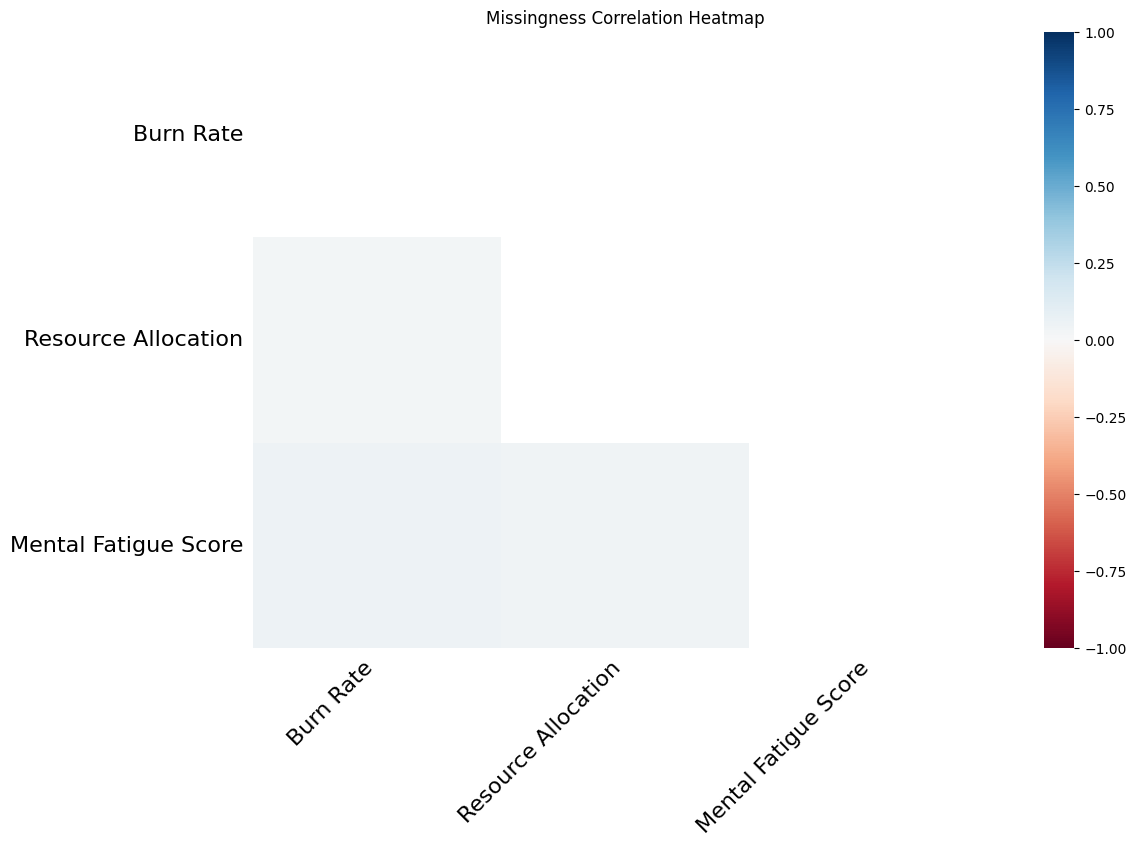

In [24]:
import missingno as msno
import matplotlib.pyplot as plt

null_cols = ["Burn Rate"] + [col for col in df.columns
                            if df[col].isna().any() and col != "Burn Rate"]

msno.heatmap(df[null_cols], figsize=(12, 8))
plt.title("Missingness Correlation Heatmap")
plt.show()

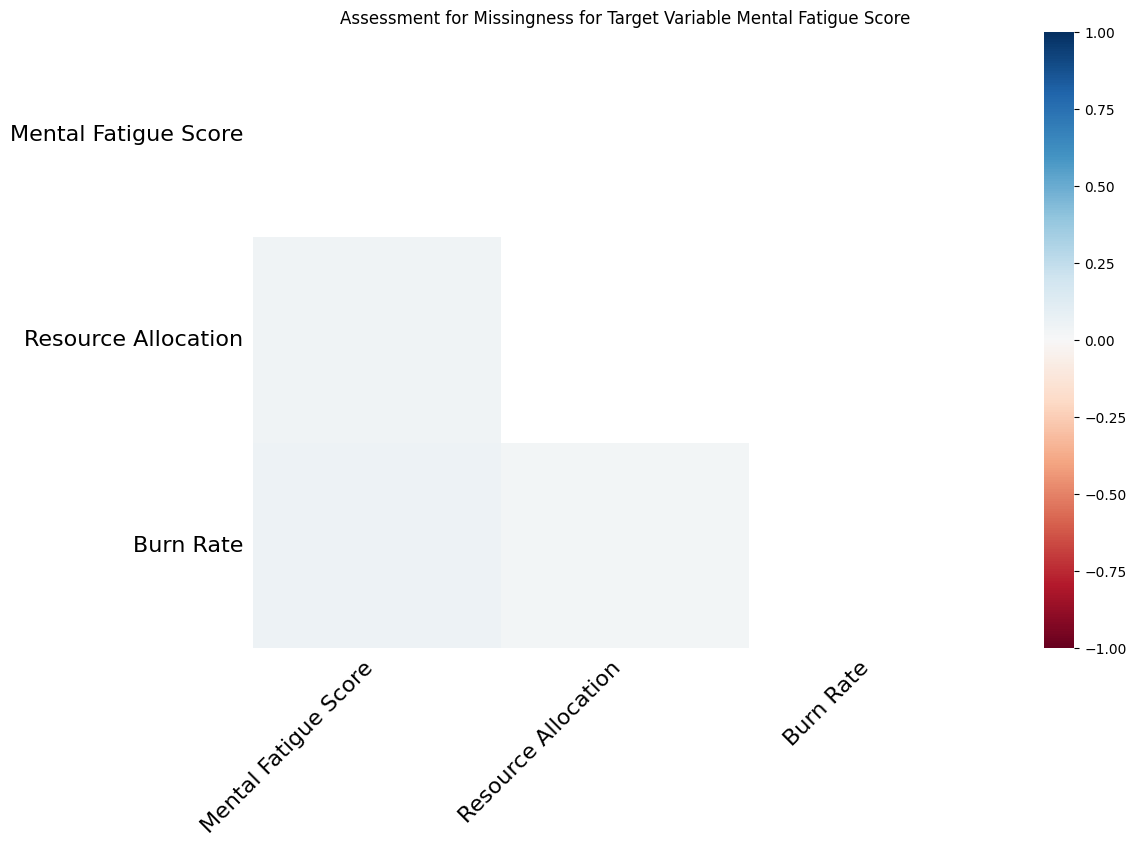

In [25]:
import missingno as msno
import matplotlib.pyplot as plt

null_cols = ["Mental Fatigue Score"] + [col for col in df.columns
                            if df[col].isna().any() and col != "Mental Fatigue Score"]

msno.heatmap(df[null_cols], figsize=(12, 8))
plt.title("Assessment for Missingness for Target Variable Mental Fatigue Score")
plt.show()

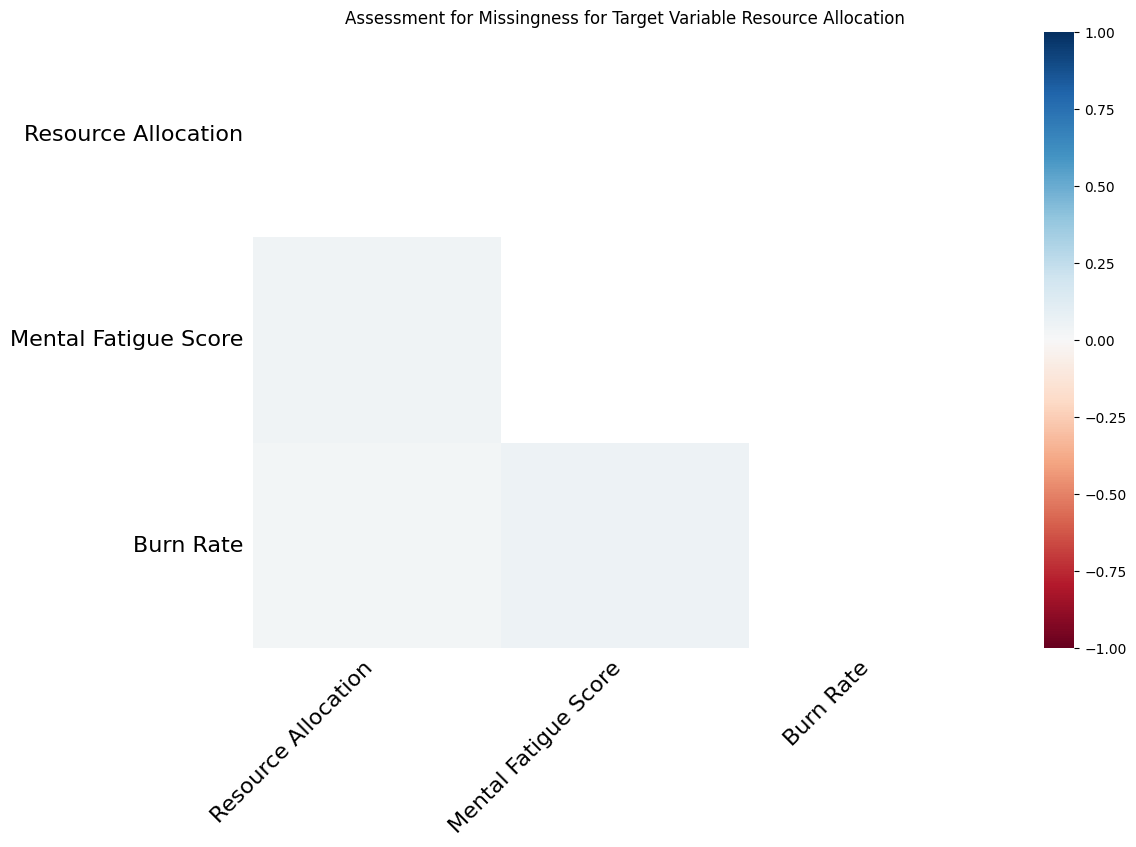

In [26]:
import missingno as msno
import matplotlib.pyplot as plt

null_cols = ["Resource Allocation"] + [col for col in df.columns
                            if df[col].isna().any() and col != "Resource Allocation"]

msno.heatmap(df[null_cols], figsize=(12, 8))
plt.title("Assessment for Missingness for Target Variable Resource Allocation")
plt.show()

**Return Proportion of Missing Values by Column**

In [27]:
df.isna().sum() / len(train)

,0
Designation,0.000000
Resource Allocation,0.060703
Mental Fatigue Score,0.093055
Burn Rate,0.049407
days_since_joined,0.000000
gender,0.000000
company_type,0.000000
is_wfh,0.000000
High Burnout,0.000000
Burnout Risk Factor,0.000000


**Drop Missing Values for Burn Rate**<br>
**Impute Mental Fatigue Score & Resource Allocation with empirical probabilistic imputation & median as baseline**<br>

Mental Fatigue Score: MCAR-consistent
Resource Allocation: MCAR-consistent

Mental fatigue score & resource allocation is closer to MCAR since none of the p-values were small enough to be significant.

Although, mental fatigue score could be NMAR since workers with extremely high mental fatigue score would be hesitant to share it, we can not test for this with the data.

For MCAR, empirical probabilistic imputation is the strongest fit. You fill missing values by randomly sampling from the observed values in that same column. Under MCAR this method gives unbiased estimates of the true mean and variance, unlike single-value imputation.

**Feature Engineering**

In [28]:
df["Workload Fatigue Interaction"] = df["Resource Allocation"] * df["Mental Fatigue Score"]
df.head(5)

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Workload Fatigue Interaction
0,2.0,3.0,3.8,0.16,92,0,1,0,False,Low Risk,False,True,False,11.4
1,1.0,2.0,5.0,0.36,31,1,1,1,False,Moderate Risk,False,False,True,10.0
2,2.0,NaN,5.8,0.49,296,0,0,1,True,Moderate Risk,False,False,True,NaN
3,1.0,1.0,2.6,0.20,58,1,1,1,False,Low Risk,False,True,False,2.6
4,3.0,7.0,6.9,0.52,160,0,1,0,True,Moderate Risk,False,False,True,48.3


In [29]:
df["Fatigue Ratio"] = df["Mental Fatigue Score"] / df["Resource Allocation"]
df.head(5)

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Workload Fatigue Interaction,Fatigue Ratio
0,2.0,3.0,3.8,0.16,92,0,1,0,False,Low Risk,False,True,False,11.4,1.266667
1,1.0,2.0,5.0,0.36,31,1,1,1,False,Moderate Risk,False,False,True,10.0,2.500000
2,2.0,NaN,5.8,0.49,296,0,0,1,True,Moderate Risk,False,False,True,NaN,NaN
3,1.0,1.0,2.6,0.20,58,1,1,1,False,Low Risk,False,True,False,2.6,2.600000
4,3.0,7.0,6.9,0.52,160,0,1,0,True,Moderate Risk,False,False,True,48.3,0.985714


In [30]:
df["High Workload"] = np.where(df["Resource Allocation"] > df["Resource Allocation"].median(), True, False)
df.head(5)

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Workload Fatigue Interaction,Fatigue Ratio,High Workload
0,2.0,3.0,3.8,0.16,92,0,1,0,False,Low Risk,False,True,False,11.4,1.266667,False
1,1.0,2.0,5.0,0.36,31,1,1,1,False,Moderate Risk,False,False,True,10.0,2.500000,False
2,2.0,NaN,5.8,0.49,296,0,0,1,True,Moderate Risk,False,False,True,NaN,NaN,False
3,1.0,1.0,2.6,0.20,58,1,1,1,False,Low Risk,False,True,False,2.6,2.600000,False
4,3.0,7.0,6.9,0.52,160,0,1,0,True,Moderate Risk,False,False,True,48.3,0.985714,True


In [31]:
df["High Fatigue"] = np.where(df["Mental Fatigue Score"] > df["Mental Fatigue Score"].median(), True, False)
df.head(5)

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue
0,2.0,3.0,3.8,0.16,92,0,1,0,False,Low Risk,False,True,False,11.4,1.266667,False,False
1,1.0,2.0,5.0,0.36,31,1,1,1,False,Moderate Risk,False,False,True,10.0,2.500000,False,False
2,2.0,NaN,5.8,0.49,296,0,0,1,True,Moderate Risk,False,False,True,NaN,NaN,False,False
3,1.0,1.0,2.6,0.20,58,1,1,1,False,Low Risk,False,True,False,2.6,2.600000,False,False
4,3.0,7.0,6.9,0.52,160,0,1,0,True,Moderate Risk,False,False,True,48.3,0.985714,True,True


In [32]:
df["Stress Index"] = 0.7 * df["Mental Fatigue Score"] + 0.3 * df["Resource Allocation"]
df.head(5)

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,days_since_joined,gender,company_type,is_wfh,High Burnout,Burnout Risk Factor,Burnout Risk Factor_High Risk,Burnout Risk Factor_Low Risk,Burnout Risk Factor_Moderate Risk,Workload Fatigue Interaction,Fatigue Ratio,High Workload,High Fatigue,Stress Index
0,2.0,3.0,3.8,0.16,92,0,1,0,False,Low Risk,False,True,False,11.4,1.266667,False,False,3.56
1,1.0,2.0,5.0,0.36,31,1,1,1,False,Moderate Risk,False,False,True,10.0,2.500000,False,False,4.10
2,2.0,NaN,5.8,0.49,296,0,0,1,True,Moderate Risk,False,False,True,NaN,NaN,False,False,NaN
3,1.0,1.0,2.6,0.20,58,1,1,1,False,Low Risk,False,True,False,2.6,2.600000,False,False,2.12
4,3.0,7.0,6.9,0.52,160,0,1,0,True,Moderate Risk,False,False,True,48.3,0.985714,True,True,6.93


**Final train dataset including all row drops, imputations, and feature engineering from above.**

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Start from raw dataframe
df_clean = train.copy()

# Drop Employee ID
df_clean = df_clean.drop(columns=["Employee ID"])

# Drop rows where Burn Rate is null
df_clean = df_clean.dropna(subset=["Burn Rate"]).copy()

# Convert Date of Joining to days_since_joined using 2008-12-31 as reference
df_clean["Date of Joining"] = pd.to_datetime(df_clean["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df_clean["days_since_joined"] = (reference_date - df_clean["Date of Joining"]).dt.days
df_clean = df_clean.drop(columns=["Date of Joining"])

# Binary encoding
# gender: Male = 1, Female = 0
# company_type: Service = 1, Product = 0
# is_wfh: Yes = 1, No = 0
df_clean["gender"] = df_clean["Gender"].map({"Male": 1, "Female": 0})
df_clean["company_type"] = df_clean["Company Type"].map({"Service": 1, "Product": 0})
df_clean["is_wfh"] = df_clean["WFH Setup Available"].map({"Yes": 1, "No": 0})

df_clean = df_clean.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

# Columns to impute
cols_to_impute = ["Mental Fatigue Score", "Resource Allocation"]

# -----------------------------
# Median-imputed + engineered + scaled dataset
# -----------------------------
df_median = df_clean.copy()

for col in cols_to_impute:
    df_median[col] = df_median[col].fillna(df_median[col].median())

# Feature engineering
df_median["Workload Fatigue Interaction"] = df_median["Resource Allocation"] * df_median["Mental Fatigue Score"]
df_median["Fatigue Ratio"] = df_median["Mental Fatigue Score"] / df_median["Resource Allocation"]
df_median["High Workload"] = np.where(
    df_median["Resource Allocation"] > df_median["Resource Allocation"].median(), 1, 0
)
df_median["High Fatigue"] = np.where(
    df_median["Mental Fatigue Score"] > df_median["Mental Fatigue Score"].median(), 1, 0
)
df_median["Stress Index"] = (
    0.7 * df_median["Mental Fatigue Score"] + 0.3 * df_median["Resource Allocation"]
)

# Continuous columns to scale
scale_cols = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined",
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "Stress Index"
]

scaler_median = StandardScaler()
df_median[scale_cols] = scaler_median.fit_transform(df_median[scale_cols])

# -----------------------------
# Empirical probabilistic-imputed + engineered + scaled dataset
# -----------------------------
df_prob = df_clean.copy()
rng = np.random.default_rng(42)

for col in cols_to_impute:
    missing_mask = df_prob[col].isna()
    observed_values = df_prob.loc[~missing_mask, col].values
    df_prob.loc[missing_mask, col] = rng.choice(
        observed_values,
        size=missing_mask.sum(),
        replace=True
    )

# Feature engineering
df_prob["Workload Fatigue Interaction"] = df_prob["Resource Allocation"] * df_prob["Mental Fatigue Score"]
df_prob["Fatigue Ratio"] = df_prob["Mental Fatigue Score"] / df_prob["Resource Allocation"]
df_prob["High Workload"] = np.where(
    df_prob["Resource Allocation"] > df_prob["Resource Allocation"].median(), 1, 0
)
df_prob["High Fatigue"] = np.where(
    df_prob["Mental Fatigue Score"] > df_prob["Mental Fatigue Score"].median(), 1, 0
)
df_prob["Stress Index"] = (
    0.7 * df_prob["Mental Fatigue Score"] + 0.3 * df_prob["Resource Allocation"]
)

scaler_prob = StandardScaler()
df_prob[scale_cols] = scaler_prob.fit_transform(df_prob[scale_cols])

print("Median-imputed + engineered + scaled dataset preview:")
print(df_median.head())

print("\nProbabilistic-imputed + engineered + scaled dataset preview:")
print(df_prob.head())

Median-imputed + engineered + scaled dataset preview:
   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0    -0.157448            -0.731293             -1.061201       0.16   
1    -1.038193            -1.233817             -0.406527       0.36   
2    -0.157448            -0.228769              0.029922       0.49   
3    -1.038193            -1.736341             -1.715875       0.20   
4     0.723298             1.278804              0.630040       0.52   

   days_since_joined  gender  company_type  is_wfh  \
0          -0.860105       0             1       0   
1          -1.438959       1             1       1   
2           1.075734       0             0       1   
3          -1.182745       1             1       1   
4          -0.214825       0             1       0   

   Workload Fatigue Interaction  Fatigue Ratio  High Workload  High Fatigue  \
0                     -0.905036      -0.284519              0             0   
1                     -0.98002

**Use df_prob as the main and df_median as the baseline**